## AMAZON ALEXA REVIEW - SENTIMENT ANALYSIS

Analyzing amazon alexa reviews using the classifation predictive model to categorize the sentiment of the review is positive or not.

In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.stem import PorterStemmer
nltk.download('stopwords')
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from wordcloud import WordCloud
import pickle
import re

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Exploratory Data Analysis

In [4]:
#loading the data

data = pd.read_csv(r"Data\amazon_alexa.tsv", delimiter = '\t', quoting = 3)

print(f'Dataset shape : {data.shape}')

Dataset shape : (3150, 5)


In [5]:
data.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"""Sometimes while playing a game, you can answe...",1
3,5,31-Jul-18,Charcoal Fabric,"""I have had a lot of fun with this thing. My 4...",1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [6]:
#null values

data.isnull().sum()

rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64

In [7]:
data[data['verified_reviews'].isnull()==True]

,rating,date,variation,verified_reviews,feedback
473,2,29-Jun-18,White,NaN,0


In [8]:
#dropped null value

data.dropna(inplace=True)

In [9]:
print(f'Dataset shape after dropping the null value : {data.shape}')

Dataset shape after dropping the null value : (3149, 5)


In [10]:
#create length column 

data['length'] = data['verified_reviews'].apply(len)

In [11]:
data.head()

,rating,date,variation,verified_reviews,feedback,length
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1,13
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1,9
2,4,31-Jul-18,Walnut Finish,"""Sometimes while playing a game, you can answe...",1,197
3,5,31-Jul-18,Charcoal Fabric,"""I have had a lot of fun with this thing. My 4...",1,174
4,5,31-Jul-18,Charcoal Fabric,Music,1,5


In [12]:
#random check

print(f'Review: {data['verified_reviews'].iloc[10]}')
print(f'Original Length of the review : {len(data['verified_reviews'].iloc[10])}')
print(f'Value in length column : {data['length'].iloc[10]}')

Review: "I sent it to my 85 year old Dad, and he talks to it constantly."
Original Length of the review : 65
Value in length column : 65


In [13]:
#datatypes
data.dtypes

rating               int64
date                object
variation           object
verified_reviews    object
feedback             int64
length               int64
dtype: object

- rating, feedback, length are integer data types
- date, variation, verified_reviews are object data types

## Analyzing rating column

In [16]:
print(f'Rating value count : {data['rating'].value_counts()}')

Rating value count : rating
5    2286
4     455
1     161
3     152
2      95
Name: count, dtype: int64


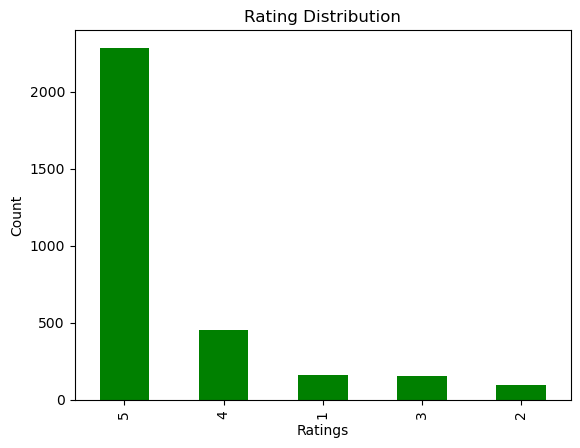

In [17]:
#plotting a bar graph
data['rating'].value_counts().plot.bar(color='green')
plt.title('Rating Distribution')
plt.xlabel('Ratings')
plt.ylabel('Count')
plt.show()

## Analyzing feedback column

In [19]:
data['feedback'].value_counts()

feedback
1    2893
0     256
Name: count, dtype: int64

There are 2 values in feedback column, 0 and 1.

In [21]:
data[data['feedback']==0].iloc[1]['verified_reviews']

'Sound is terrible if u want good music too get a bose'

In [22]:
data[data['feedback']==1].iloc[1]['verified_reviews']

'Loved it!'

This shows the 0 in the feedback column represents a negative feedback whereas 1 represents a positive feedback.

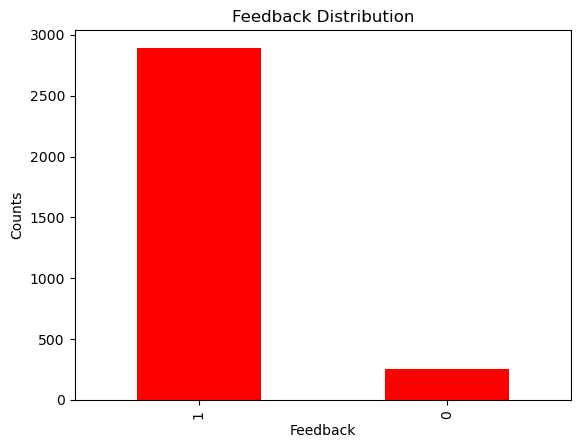

In [24]:
#plotting a bar graph
data['feedback'].value_counts().plot.bar(color = 'red')
plt.title('Feedback Distribution')
plt.xlabel('Feedback')
plt.ylabel('Counts')
plt.show()

In [25]:
# finding percentage distribution of the feedback column

print(f'Feedback value count : Percentage Distribution \n{round(data['feedback'].value_counts()/data.shape[0]*100,2)}')

Feedback value count : Percentage Distribution 
feedback
1    91.87
0     8.13
Name: count, dtype: float64


<Axes: title={'center': 'Precentage wise distribution of the feedback'}, ylabel='count'>

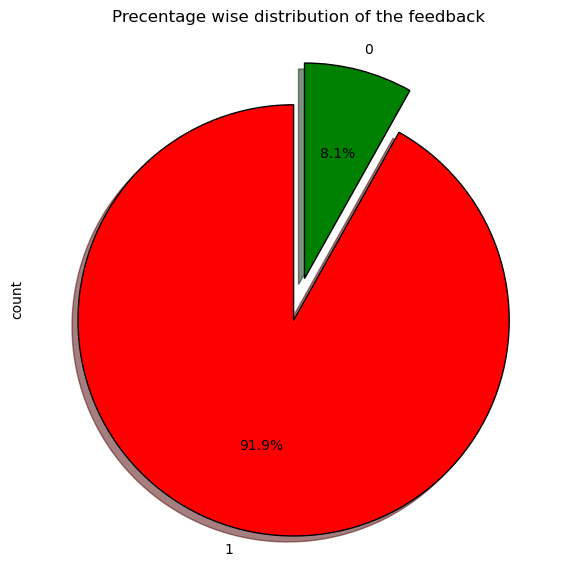

In [26]:
fig = plt.figure(figsize=(7,7))

colors = ('red', 'green')
wp = {'linewidth':1, 'edgecolor': 'black'}
tags = data['feedback'].value_counts()/data.shape[0]
explodes = (0.1,0.1)
tags.plot(kind='pie', autopct='%1.1f%%', shadow=True, colors=colors, startangle=90, wedgeprops=wp, explode=explodes, title='Precentage wise distribution of the feedback')

In [27]:
#feedback=0

data[data['feedback']==0]['rating'].value_counts()

rating
1    161
2     95
Name: count, dtype: int64

In [28]:
#feedback=1

data[data['feedback']==1]['rating'].value_counts()

rating
5    2286
4     455
3     152
Name: count, dtype: int64

If the rating is 1 or 2 then it is a negative feedback whereas, if the rating 3,4 or 5 then it is a positive feedback.

## Analyzing variation column

In [31]:
data['variation'].value_counts()

variation
Black  Dot                      516
Charcoal Fabric                 430
Configuration: Fire TV Stick    350
Black  Plus                     270
Black  Show                     265
Black                           261
Black  Spot                     241
White  Dot                      184
Heather Gray Fabric             157
White  Spot                     109
Sandstone Fabric                 90
White                            90
White  Show                      85
White  Plus                      78
Oak Finish                       14
Walnut Finish                     9
Name: count, dtype: int64

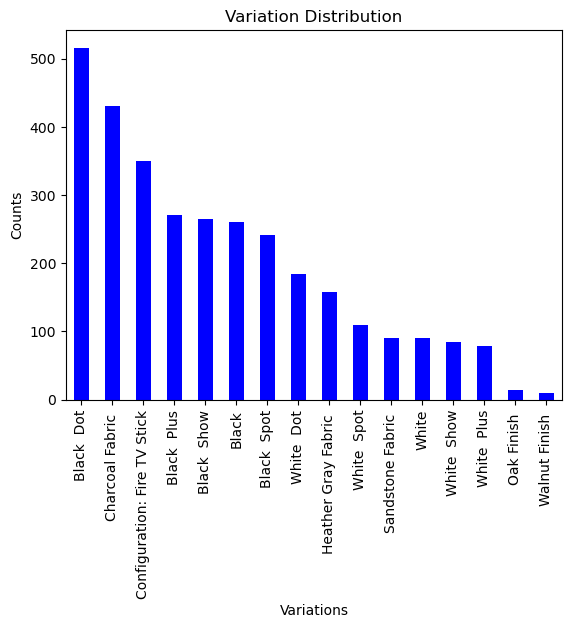

In [32]:
#plotting the bar graph

data['variation'].value_counts().plot.bar(color = 'blue')
plt.title('Variation Distribution')
plt.xlabel('Variations')
plt.ylabel('Counts')
plt.show()

Mean rating w.r.t variation

In [34]:
data.groupby('variation')['rating'].mean()

variation
Black                           4.233716
Black  Dot                      4.453488
Black  Plus                     4.370370
Black  Show                     4.490566
Black  Spot                     4.311203
Charcoal Fabric                 4.730233
Configuration: Fire TV Stick    4.591429
Heather Gray Fabric             4.694268
Oak Finish                      4.857143
Sandstone Fabric                4.355556
Walnut Finish                   4.888889
White                           4.166667
White  Dot                      4.423913
White  Plus                     4.358974
White  Show                     4.282353
White  Spot                     4.311927
Name: rating, dtype: float64

Analyze above rating

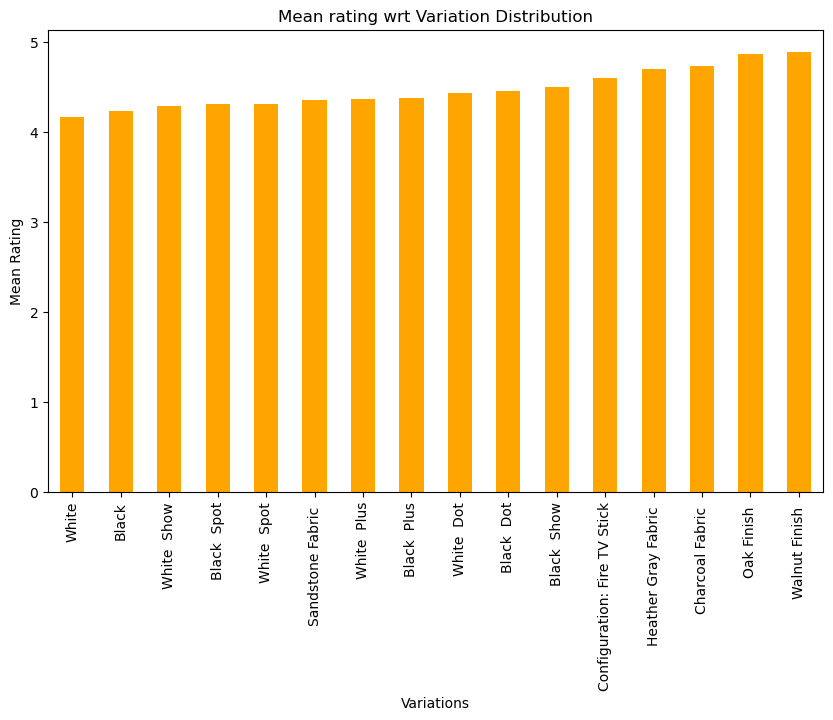

In [36]:
data.groupby('variation')['rating'].mean().sort_values().plot.bar(color='orange', figsize=(10,6))
plt.title('Mean rating wrt Variation Distribution')
plt.xlabel('Variations')
plt.ylabel('Mean Rating')
plt.show()

## Analyzing verified_reviews column

In [38]:
data['length'].describe()

count    3149.000000
mean      132.714513
std       182.541531
min         1.000000
25%        30.000000
50%        74.000000
75%       166.000000
max      2853.000000
Name: length, dtype: float64

[Text(0.5, 1.0, 'Distribution of the length of the reviews.')]

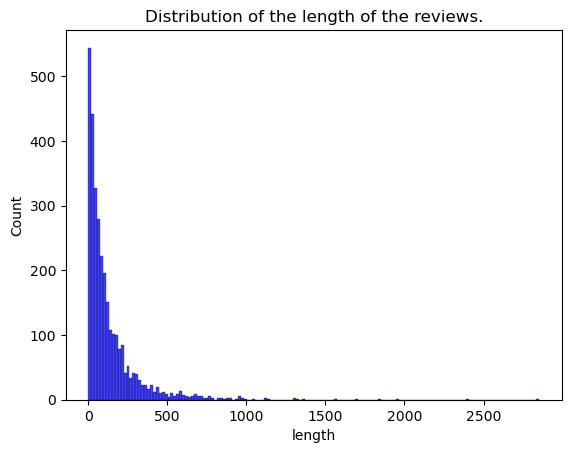

In [39]:
sns.histplot(data['length'], color='blue').set(title='Distribution of the length of the reviews.')

[Text(0.5, 1.0, 'Distribution of the length of the negative reviews.')]

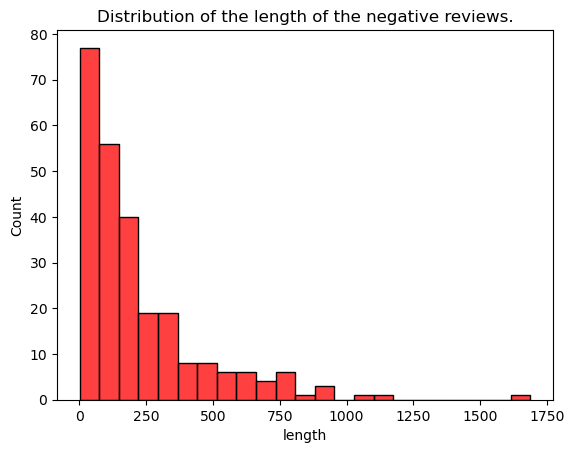

In [40]:
#length analysis when feedback is negative
sns.histplot(data[data['feedback']==0]['length'], color='red').set(title='Distribution of the length of the negative reviews.')


[Text(0.5, 1.0, 'Distribution of the length of the positive reviews.')]

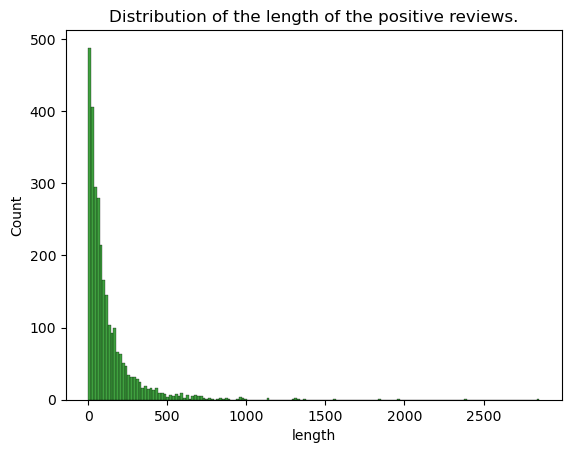

In [41]:
#length analysis when feedback is positive
sns.histplot(data[data['feedback']==1]['length'], color='green').set(title='Distribution of the length of the positive reviews.')


In [42]:
cv = CountVectorizer(stop_words='english')
words = cv.fit_transform(data.verified_reviews)

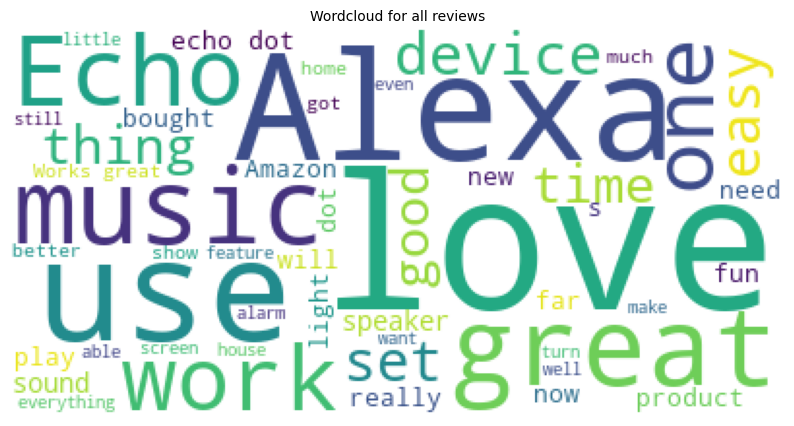

In [43]:
#combine all reviews
reviews = " ".join([review for review in data['verified_reviews']])

#initialize wordcloud
wc = WordCloud(background_color='white', max_words=50 )

#generate and plot wordcloud
plt.figure(figsize=(10,10))
plt.imshow(wc.generate(reviews))
plt.title('Wordcloud for all reviews', fontsize=10)
plt.axis('off')
plt.show()

Let's find out unique words in each feedback category

In [45]:
#combiing all reviews in each feedback category and then splitting it into words
neg_reviews = " ".join([review for review in data[data['feedback']==0]['verified_reviews']])
neg_reviews=neg_reviews.lower().split()

pos_reviews=" ".join([review for review in data[data['feedback']==1]['verified_reviews']])
pos_reviews=pos_reviews.lower().split()

#finiding words from reviews which are present in that feedback category only
unique_negative = [x for x in neg_reviews if x not in pos_reviews]
unique_negative = " ".join(unique_negative)

unique_positive = [x for x in pos_reviews if x not in neg_reviews]
unique_positive= " ".join(unique_positive)

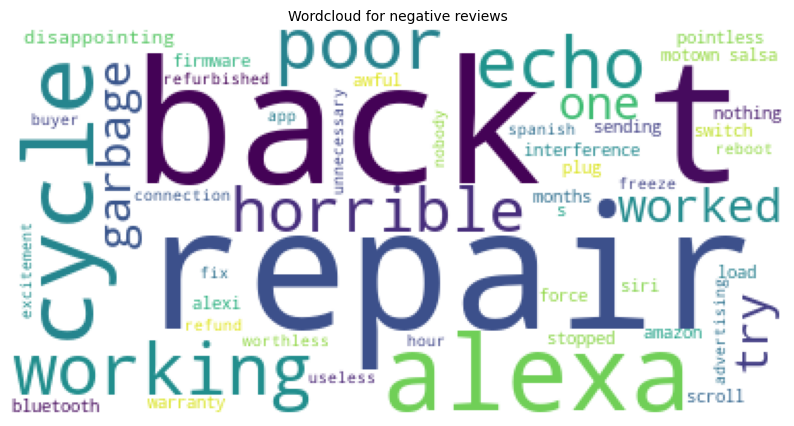

In [46]:
#initialize wordcloud
wc = WordCloud(background_color='white', max_words=50 )

#generate and plot wordcloud for negative reviews
plt.figure(figsize=(10,10))
plt.imshow(wc.generate(unique_negative))
plt.title('Wordcloud for negative reviews', fontsize=10)
plt.axis('off')
plt.show()

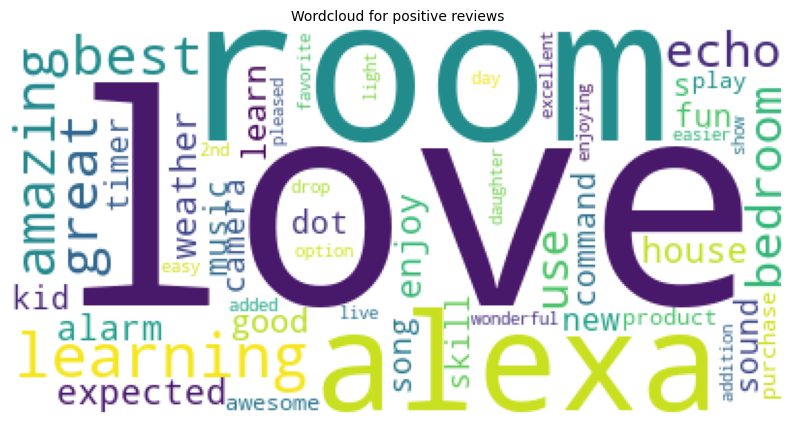

In [47]:
#generate and plot wordcloud for negative reviews
plt.figure(figsize=(10,10))
plt.imshow(wc.generate(unique_positive))
plt.title('Wordcloud for positive reviews', fontsize=10)
plt.axis('off')
plt.show()

## Preprocessing and Modelling

To build the corpus from 'verified_reviews', we perform the following:

1) Replace any non alphatic character with space.
2) Convert into lower case and split it into words.
3) Iterate over the individual words and if it is not a stopword then add the stemmed form of the word to the corpus.

In [98]:
corpus=[]
stemmer = PorterStemmer()
for i in range(0, data.shape[0]):
    review=re.sub('[^a-zA-Z]', ' ' , data.iloc[i]['verified_reviews'])
    review=review.lower().split()
    review= [stemmer.stem(word) for word in review if not word in STOPWORDS]
    review=' '.join(review)
    corpus.append(review)

Using Count Vector to create bag of words

In [101]:
cv = CountVectorizer(max_features=2500)

X=cv.fit_transform(corpus).toarray()
y=data['feedback'].values

In [109]:
#saving the count vectorizer
pickle.dump(cv, open('Models/countvectorizer.pkl', 'wb'))

In [111]:
#checking the shape of X and y
print(f'Shape of X : {X.shape}')
print(f'Shape of y : {y.shape}')

Shape of X : (3149, 2500)
Shape of y : (3149,)


Splitting data into test and train

In [116]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state= 15)

print(f'X train :{X_train.shape}')
print(f'X test :{X_test.shape}')
print(f'y train :{y_train.shape}')
print(f'y test :{y_test.shape}')

X train :(2204, 2500)
X test :(945, 2500)
y train :(2204,)
y test :(945,)


In [118]:
print(f'Maximum value in X train : {X_train.max()}')
print(f'Maximum value in X test : {X_test.max()}')

Maximum value in X train : 12
Maximum value in X test : 10


In [124]:
scaler=MinMaxScaler()

X_train_scl = scaler.fit_transform(X_train)
X_test_scl = scaler.fit_transform(X_test)

In [126]:
#saving the sclaer model
pickle.dump(scaler, open('Models/scaler.pkl', 'wb'))

## Random Forest

In [132]:
model_rf = RandomForestClassifier()
model_rf.fit(X_train_scl, y_train)

RandomForestClassifier()

In [138]:
#checking the accuracy
print('Accuracy of training model:', model_rf.score(X_train_scl,y_train))
print('Accuracy of testing model:', model_rf.score(X_test_scl,y_test))

Accuracy of training model: 0.9945553539019963
Accuracy of testing model: 0.9407407407407408


In [140]:
#predicting
y_pred = model_rf.predict(X_test_scl) 

In [144]:
cm = confusion_matrix(y_test,y_pred)

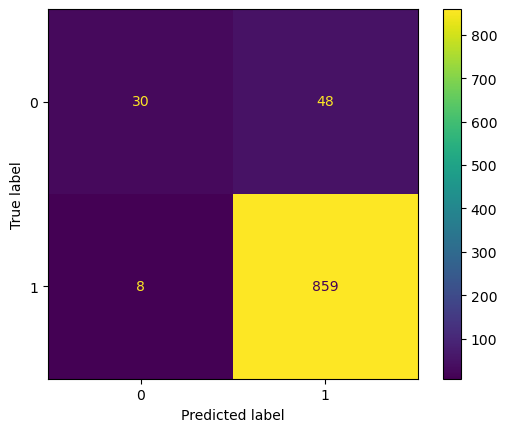

In [148]:
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=model_rf.classes_)
cm_display.plot()
plt.show()

K fold cross-validation

In [159]:
accuracies = cross_val_score(estimator = model_rf, X = X_train_scl, y = y_train, cv = 10)

print("Accuracy :", accuracies.mean())
print("Standard Variance :", accuracies.std())

Accuracy : 0.9333093377211025
Standard Variance : 0.00881181508497347


In [161]:
#Applying grid search to get the optimal parameters on random forest

params = {
    'bootstrap': [True],
    'max_depth': [80, 100],
    'min_samples_split': [8, 12],
    'n_estimators': [100, 300]
}

In [163]:
cv_object = StratifiedKFold(n_splits = 2)

grid_search = GridSearchCV(estimator = model_rf, param_grid = params, cv = cv_object, verbose = 0, return_train_score = True)
grid_search.fit(X_train_scl, y_train.ravel())

GridSearchCV(cv=StratifiedKFold(n_splits=2, random_state=None, shuffle=False),
             estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True], 'max_depth': [80, 100],
                         'min_samples_split': [8, 12],
                         'n_estimators': [100, 300]},
             return_train_score=True)

In [165]:
#Getting the best parameters from the grid search
print("Best Parameter Combination : {}".format(grid_search.best_params_))

Best Parameter Combination : {'bootstrap': True, 'max_depth': 100, 'min_samples_split': 8, 'n_estimators': 300}


In [169]:
print("Cross validation mean accuracy on train set : {}".format(grid_search.cv_results_['mean_train_score'].mean()*100))
print("Cross validation mean accuracy on test set : {}".format(grid_search.cv_results_['mean_test_score'].mean()*100))
print("Accuracy score for test set :", accuracy_score(y_test, y_pred))

Cross validation mean accuracy on train set : 96.85231397459165
Cross validation mean accuracy on test set : 92.11093466424683
Accuracy score for test set : 0.9407407407407408


## XgBoost

In [173]:
model_xgb = XGBClassifier()
model_xgb.fit(X_train_scl, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [175]:
#Accuracy of the model on training and testing data
 
print("Training Accuracy :", model_xgb.score(X_train_scl, y_train))
print("Testing Accuracy :", model_xgb.score(X_test_scl, y_test))

Training Accuracy : 0.9718693284936479
Testing Accuracy : 0.9333333333333333


In [179]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 30  48]
 [  8 859]]


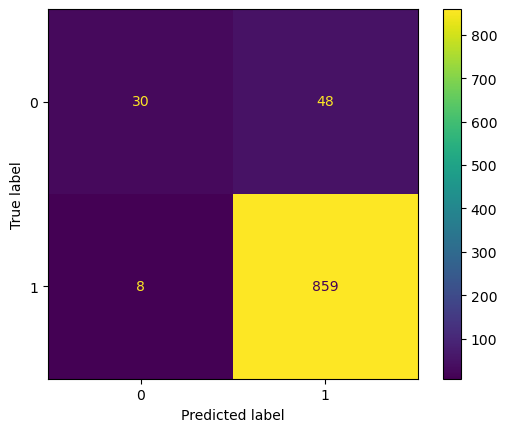

In [181]:
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model_xgb.classes_)
cm_display.plot()
plt.show()

In [183]:
#Saving the XGBoost classifier
pickle.dump(model_xgb, open('Models/model_xgb.pkl', 'wb'))

## Decision Tree Classifier

In [187]:
model_dt = DecisionTreeClassifier()
model_dt.fit(X_train_scl, y_train)

DecisionTreeClassifier()

In [189]:
#Accuracy of the model on training and testing data
 
print("Training Accuracy :", model_dt.score(X_train_scl, y_train))
print("Testing Accuracy :", model_dt.score(X_test_scl, y_test))

Training Accuracy : 0.9945553539019963
Testing Accuracy : 0.9068783068783068


In [191]:
y_preds = model_dt.predict(X_test)

In [193]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_preds)
print(cm)

[[ 41  37]
 [ 90 777]]


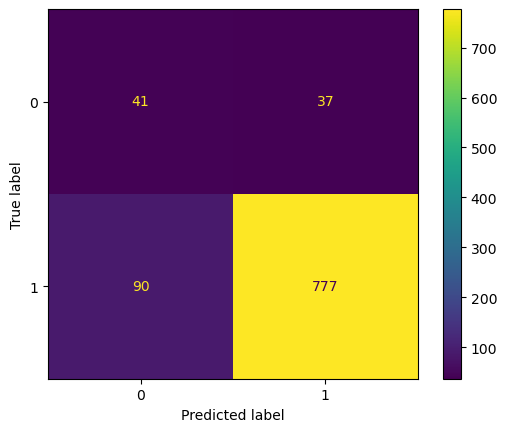

In [195]:
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model_dt.classes_)
cm_display.plot()
plt.show()